# EDACM Collision Outcomes

This notebook demonstrates how to apply the optional AccreDiff EDACM collision-outcome module to a real N-body collision file. It reads the `note_02` GENGA-style collision record, converts the stored quantities to SI units, derives impact velocity, impact angle, and impact parameter, and appends EDACM outcome diagnostics.


---
## 1. Setup

The EDACM classifier expects SI units: mass in kg, radius in m, velocity in m s$^{-1}$, and dimensionless impact parameter $b$. The bundled `note_02` collision file stores masses in solar masses, lengths in AU, and velocities in GENGA-like code units.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = None
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "accrediff").exists():
        PROJECT_ROOT = parent
        sys.path.insert(0, str(parent / "src"))
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the AccreDiff repository root.")

import accrediff as ad

pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 4)


---
## 2. Load and Preprocess the Collision File

The column layout follows the convention used in `examples/Accrection/A_Embryos_Composition.ipynb`. The first two bodies in the example dataset are massive outer planets, so we apply the same `index >= 2` terrestrial-body filtering convention used in the accretion notebooks.

The impact angle is derived from the relative position and velocity vectors,

$$
\cos \theta = \frac{|\Delta \mathbf{r} \cdot \Delta \mathbf{v}|}{|\Delta \mathbf{r}| |\Delta \mathbf{v}|},
\qquad b = \sin\theta .
$$

Here $\theta=0$ denotes a head-on impact and $\theta=90^\circ$ denotes a grazing impact.


In [2]:
GENGA_COLLISION_COLUMNS = [
    "time",
    "indexi", "mi", "ri", "xi", "yi", "zi", "vxi", "vyi", "vzi", "Sxi", "Syi", "Szi",
    "indexj", "mj", "rj", "xj", "yj", "zj", "vxj", "vyj", "vzj", "Sxj", "Syj", "Szj",
]

AU_M = 1.495978707e11
M_SUN_KG = 1.98847e30
YEAR_S = 365.25 * 24 * 3600
GENGA_VELOCITY_M_S = 2.0 * np.pi * AU_M / YEAR_S


def load_genga_collision_file(model="note_02"):
    model_path = PROJECT_ROOT / "examples" / "dataset" / "N_body_dataset" / model
    collision_files = sorted(model_path.glob("Collision*.dat"))
    if not collision_files:
        raise FileNotFoundError(f"No Collision*.dat file found in {model_path}")

    df = pd.read_csv(
        collision_files[0],
        sep=r"\s+",
        header=None,
        names=GENGA_COLLISION_COLUMNS,
    )
    return df, collision_files[0]


def prepare_genga_collisions_for_edacm(df):
    out = df.copy()

    r_i = out[["xi", "yi", "zi"]].to_numpy(dtype=float)
    r_j = out[["xj", "yj", "zj"]].to_numpy(dtype=float)
    v_i = out[["vxi", "vyi", "vzi"]].to_numpy(dtype=float)
    v_j = out[["vxj", "vyj", "vzj"]].to_numpy(dtype=float)

    delta_r = r_i - r_j
    delta_v = v_i - v_j
    separation = np.linalg.norm(delta_r, axis=1)
    relative_speed_code = np.linalg.norm(delta_v, axis=1)

    valid = (separation > 0.0) & (relative_speed_code > 0.0)
    if not np.all(valid):
        out = out.loc[valid].copy()
        delta_r = delta_r[valid]
        delta_v = delta_v[valid]
        separation = separation[valid]
        relative_speed_code = relative_speed_code[valid]

    cos_theta = np.abs(np.sum(delta_r * delta_v, axis=1) / (separation * relative_speed_code))
    cos_theta = np.clip(cos_theta, 0.0, 1.0)
    impact_angle_rad = np.arccos(cos_theta)

    out["m_target"] = out["mi"] * M_SUN_KG
    out["m_impactor"] = out["mj"] * M_SUN_KG
    out["r_target"] = out["ri"] * AU_M
    out["r_impactor"] = out["rj"] * AU_M
    out["v_impact"] = relative_speed_code * GENGA_VELOCITY_M_S
    out["impact_angle_rad"] = impact_angle_rad
    out["impact_angle_deg"] = np.degrees(impact_angle_rad)
    out["b"] = np.sin(impact_angle_rad)
    out["separation_au"] = separation
    out["separation_contact_ratio"] = separation / (out["ri"] + out["rj"])
    out["m_target_mearth"] = out["mi"] / ad.constants.ME
    out["m_impactor_mearth"] = out["mj"] / ad.constants.ME
    out["v_impact_km_s"] = out["v_impact"] / 1000.0

    return out


df_collision_raw, collision_path = load_genga_collision_file("note_02")
terrestrial_mask = (df_collision_raw["indexi"] >= 2) & (df_collision_raw["indexj"] >= 2)
df_collision_rocky = df_collision_raw.loc[terrestrial_mask].copy()
df_collision_edacm = prepare_genga_collisions_for_edacm(df_collision_rocky)

print(f"Collision file       : {collision_path.relative_to(PROJECT_ROOT)}")
print(f"Raw events           : {len(df_collision_raw)}")
print(f"Terrestrial events   : {len(df_collision_rocky)}")
print(f"Prepared EDACM events: {len(df_collision_edacm)}")
print()
print("Unit-converted diagnostic ranges:")
print(f"  target mass       : {df_collision_edacm['m_target_mearth'].min():.3e} - {df_collision_edacm['m_target_mearth'].max():.3e} M_earth")
print(f"  impactor mass     : {df_collision_edacm['m_impactor_mearth'].min():.3e} - {df_collision_edacm['m_impactor_mearth'].max():.3e} M_earth")
print(f"  impact velocity   : {df_collision_edacm['v_impact_km_s'].min():.2f} - {df_collision_edacm['v_impact_km_s'].max():.2f} km/s")
print(f"  impact angle      : {df_collision_edacm['impact_angle_deg'].min():.2f} - {df_collision_edacm['impact_angle_deg'].max():.2f} deg")
print(f"  b                 : {df_collision_edacm['b'].min():.3f} - {df_collision_edacm['b'].max():.3f}")
print(f"  separation/(Ri+Rj): median = {df_collision_edacm['separation_contact_ratio'].median():.4f}")

df_collision_edacm[[
    "time", "indexi", "indexj",
    "m_target_mearth", "m_impactor_mearth",
    "v_impact_km_s", "impact_angle_deg", "b", "separation_contact_ratio",
]].head()


Collision file       : examples/dataset/N_body_dataset/note_02/Collisionsnote_02.dat
Raw events           : 5790
Terrestrial events   : 5786
Prepared EDACM events: 5786

Unit-converted diagnostic ranges:
  target mass       : 4.723e-04 - 8.380e-01 M_earth
  impactor mass     : 2.185e-04 - 3.315e-01 M_earth
  impact velocity   : 0.82 - 24.04 km/s
  impact angle      : 0.87 - 88.26 deg
  b                 : 0.015 - 1.000
  separation/(Ri+Rj): median = 1.0000


,time,indexi,indexj,m_target_mearth,m_impactor_mearth,v_impact_km_s,impact_angle_deg,b,separation_contact_ratio
0,0.5191,2283,2573,0.0012,0.0008,1.0164,24.4333,0.4136,0.9999
1,0.6749,3353,3878,0.0008,0.0007,0.9139,38.4188,0.6214,0.9999
2,1.0415,2610,2686,0.0012,0.0008,1.0010,38.4868,0.6223,0.9999
3,1.8342,1607,3262,0.0007,0.0007,0.8936,42.4058,0.6744,0.9999
4,1.8836,2289,1867,0.0011,0.0008,0.9875,61.6005,0.8797,0.9999


---
## 3. Run EDACM Classification

The DataFrame wrapper `ad.add_collision_outcomes` appends EDACM diagnostics without modifying the input table in place.


In [3]:
df_real_outcomes = ad.add_collision_outcomes(df_collision_edacm)

outcome_summary = (
    df_real_outcomes["outcome"]
    .value_counts()
    .rename_axis("outcome")
    .reset_index(name="count")
)
outcome_summary["fraction"] = outcome_summary["count"] / len(df_real_outcomes)

outcome_summary


,outcome,count,fraction
0,perfect_merger,2598,0.4490
1,hit_and_run,2237,0.3866
2,hit_and_run_super_catastrophic,316,0.0546
3,partial_accretion,303,0.0524
4,erosion,175,0.0302
5,super_catastrophic,157,0.0271


In [4]:
df_real_outcomes[[
    "time", "indexi", "indexj",
    "m_target_mearth", "m_impactor_mearth",
    "v_impact_km_s", "impact_angle_deg", "b",
    "outcome", "grazing", "catastrophic",
    "m_largest_remnant_fraction",
]].head(10)


,time,indexi,indexj,m_target_mearth,m_impactor_mearth,v_impact_km_s,impact_angle_deg,b,outcome,grazing,catastrophic,m_largest_remnant_fraction
0,0.5191,2283,2573,0.0012,0.0008,1.0164,24.4333,0.4136,perfect_merger,False,False,0.9352
1,0.6749,3353,3878,0.0008,0.0007,0.9139,38.4188,0.6214,perfect_merger,True,False,0.9654
2,1.0415,2610,2686,0.0012,0.0008,1.0010,38.4868,0.6223,perfect_merger,True,False,0.9681
3,1.8342,1607,3262,0.0007,0.0007,0.8936,42.4058,0.6744,perfect_merger,True,False,0.9743
4,1.8836,2289,1867,0.0011,0.0008,0.9875,61.6005,0.8797,perfect_merger,True,False,0.9979
5,1.8926,4255,785,0.0009,0.0008,0.9528,38.6882,0.6251,perfect_merger,True,False,0.9664
6,2.1460,3503,238,0.0009,0.0006,0.9195,44.2755,0.6981,perfect_merger,True,False,0.9791
7,2.2842,5158,6553,0.0008,0.0007,0.9145,41.7536,0.6659,perfect_merger,True,False,0.9729
8,2.7366,4825,3170,0.0008,0.0007,0.9099,50.4712,0.7713,perfect_merger,True,False,0.9882
9,3.6247,2732,902,0.0009,0.0008,0.9522,79.4597,0.9831,perfect_merger,True,False,1.0000


---
## 4. Diagnostic Plot

The plot summarizes the EDACM classification in impact-velocity and impact-angle space. Marker size scales with the largest-remnant mass fraction.


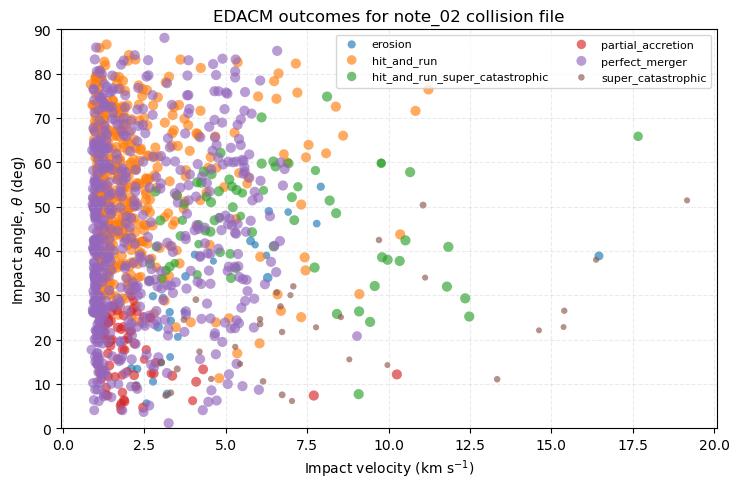

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))

sample = df_real_outcomes.copy()
if len(sample) > 1200:
    sample = sample.sample(1200, random_state=42)

for outcome, group in sample.groupby("outcome"):
    ax.scatter(
        group["v_impact_km_s"],
        group["impact_angle_deg"],
        s=18 + 36 * group["m_largest_remnant_fraction"].clip(lower=0, upper=1),
        alpha=0.65,
        edgecolor="none",
        label=outcome,
    )

ax.set_xlabel(r"Impact velocity (km s$^{-1}$)")
ax.set_ylabel(r"Impact angle, $\theta$ (deg)")
ax.set_title("EDACM outcomes for note_02 collision file")
ax.set_ylim(0, 90)
ax.grid(alpha=0.25, ls="--")
ax.legend(frameon=True, fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


---
## 5. Workflow Note

This notebook demonstrates the preprocessing and diagnostic-enrichment layer only. Mapping non-perfect-merger outcomes to AccreDiff mantle/core material budgets should be implemented as a separate coupling step, because that mapping affects mass conservation and event-by-event differentiation.
